In [936]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

In [937]:
#Constants
a,w,v,K,tau,beta,gamma=1e-3,0.8,0.024,10,30,100,10
rho=0.003
sigma_1=14.5
sigma_2=1.5

In [938]:
#Numerical intergrator settings
t_start=0
t_end=800000
transient=500000
t_eval=np.linspace(t_start, t_end, 1000000)

#Initial state of system
initialState=[0.1,0,1,12,0.1,0,1,12]

In [939]:
#ODE model for chemostat

def odeModel(t,y):
    B,I,P,S,B2,I2,P2,S2=y
    B_dot=v*B*(S/(S+K)) - B*(rho+a*w*P)
    I_dot=a*w*B*P - I*(rho + 1/tau)
    P_dot=1e-6-P*(rho + a*(B+I)) + beta*(I/tau)
    S_dot=rho*(sigma_1-S) - gamma*v*B*(S/(S+K))

    B_dot2=v*B2*(S2/(S2+K)) - B2*(rho+a*w*P2)
    I_dot2=a*w*B2*P2 - I2*(rho + 1/tau)
    P_dot2=1e-6-P2*(rho + a*(B2+I2)) + beta*(I2/tau)
    S_dot2=rho*(S + sigma_2 -S2) - gamma*v*B2*(S2/(S2+K))
        
    return [B_dot,I_dot,P_dot,S_dot,B_dot2,I_dot2,P_dot2,S_dot2]

In [940]:
#Solves the ODE model as well as removing transient time
def solveODE(t_s,t_e,i_state,integrator,dt):
    solution = solve_ivp(odeModel,
                     [t_s,t_e],
                     i_state,method=integrator, t_eval=dt)
    temp=solution.t >= transient
    return solution.y[0][temp],solution.y[1][temp],solution.y[2][temp],solution.y[3][temp],solution.y[4][temp],solution.y[5][temp],solution.y[6][temp],solution.y[7][temp]

In [941]:
#Create stable inital state
def averageSteadyState(sol):
    return np.mean(sol[0]),np.mean(sol[1]),np.mean(sol[2]),np.mean(sol[3]),np.mean(sol[4]),np.mean(sol[5]),np.mean(sol[6]),np.mean(sol[7])

In [942]:
plotData=solveODE(t_start,t_end,initialState,'RK45',t_eval)
steadyState=averageSteadyState(plotData)
initialState2=[steadyState[0],steadyState[1],steadyState[2],steadyState[3],steadyState[4],steadyState[5],steadyState[6],steadyState[7]]
plotData2=solveODE(t_start,t_end,initialState2,'RK45',t_eval)

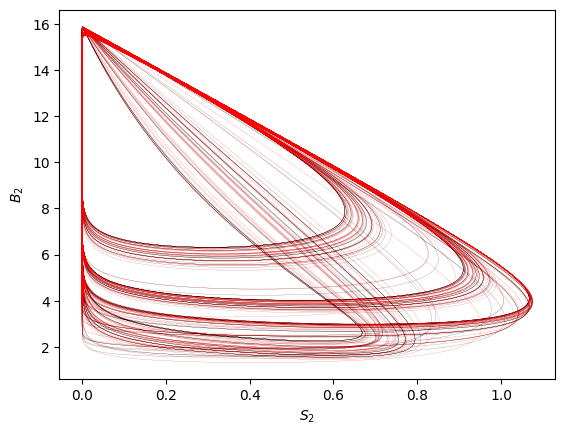

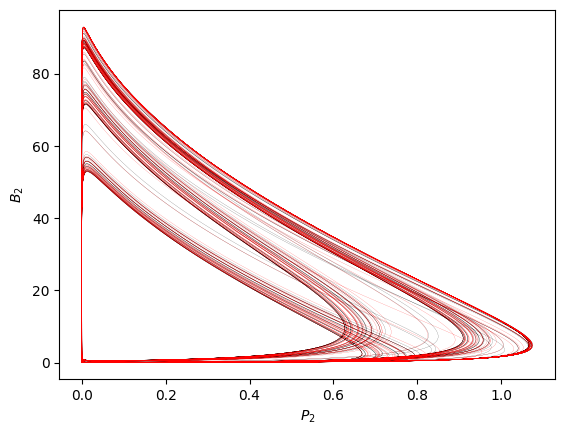

In [943]:
plt.plot(plotData[4],plotData[7],color='black',linewidth=0.1)
plt.plot(plotData2[4],plotData2[7],color='red',linewidth=0.1)
plt.xlabel("$S_2$")
plt.ylabel("$B_2$") 
plt.show()
plt.plot(plotData[4],plotData[6],color='black',linewidth=0.1)
plt.plot(plotData2[4],plotData2[6],color='red',linewidth=0.1)
plt.xlabel("$P_2$")
plt.ylabel("$B_2$") 
plt.show()

## Multistability

In [944]:
#Plot Substrate concentration against population of non infected bacteria

B2Poincare=[]
I2Poincare=[]
P2Poincare=[]
S2Poincare=[]

B2Poincare2=[]
I2Poincare2=[]
P2Poincare2=[]
S2Poincare2=[]

for i in range(len(plotData[4])):
    if plotData[7][i-1] <= 3 and plotData[7][i] >= 3:
        B2Poincare.append(plotData[4][i])
        I2Poincare.append(plotData[5][i])
        P2Poincare.append(plotData[6][i])
        S2Poincare.append(plotData[7][i])
    if plotData2[7][i-1] <= 3 and plotData2[7][i] >= 3:
        B2Poincare2.append(plotData2[4][i])
        I2Poincare2.append(plotData2[5][i])
        P2Poincare2.append(plotData2[6][i])
        S2Poincare2.append(plotData2[7][i])

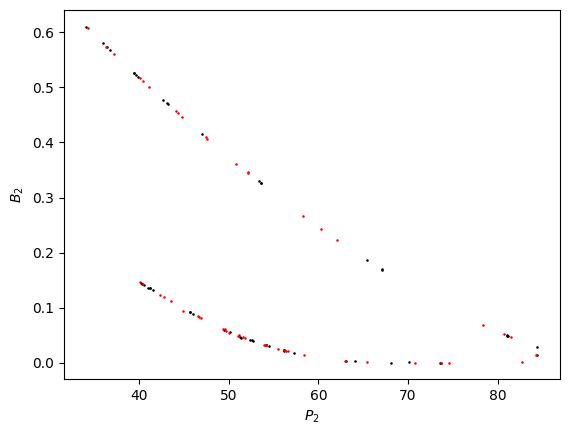

In [945]:

plt.scatter(P2Poincare,B2Poincare,color='black',s=0.7)
plt.scatter(P2Poincare2,B2Poincare2,color='red',s=0.7)
plt.xlabel("$P_2$")
plt.ylabel("$B_2$")
#plt.ylim(-0.1,1)
#plt.xlim(-10,120)

plt.show()
